# Investigating Michaelis-Menten fit to experimental data from EnzymeML paper

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # type: ignore

Glucose

In [2]:
import os
model = 'propioin_synthesis'
substrate_var = False
data_dict = {}
# Get the number of files in the specified directory
num_files = len([f for f in os.listdir(f'data/experimental/static/raw/enzymeml/{model}') if os.path.isfile(os.path.join('data/experimental/static/raw/enzymeml/pyruvate_catalysis', f))])

# Use the number of files in the range
for i in range(num_files):
    data_dict['m'+str(i)] = pd.read_csv(f'data/experimental/static/raw/enzymeml/{model}/m{str(i)}.csv', index_col=0, names=['replicate_'+str(j) for j in range(1, 4)])

In [3]:
data = data_dict['m0'].copy()

data

,replicate_1,replicate_2,replicate_3
0.0,0.000000,0.000000,0.000000
15.0,63.784611,66.106679,67.447746
30.0,77.957073,80.538850,81.174757
60.0,80.241658,85.079882,88.266513
120.0,81.314628,90.150488,85.021530


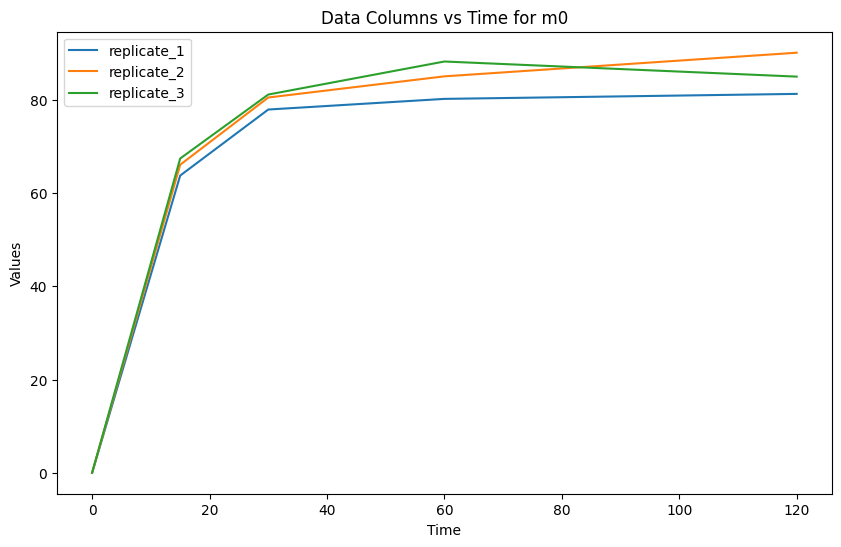

In [4]:
for key, dataset in data_dict.items():
    time = dataset.index  # Assuming the index represents time
    plt.figure(figsize=(10, 6))

    for column in dataset.columns:
        plt.plot(time, dataset[column], label=column)

    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title(f'Data Columns vs Time for {key}')
    plt.legend()
    plt.show()

In [5]:
for key, dataset in data_dict.items():
  
    if substrate_var:
    # Add substrate columns and time derivative columns
        for substrate_col in dataset.columns:
            dataset = dataset.rename(columns={col: f'product_{col.split("_")[1]}' for col in dataset.columns})
            product_col = f'substrate_{substrate_col.split("_")[1]}'
            derivative_col = f'derivative_{substrate_col.split("_")[1]}'
            
            dataset[product_col] = 1 - dataset[substrate_col]
            # Fit the product column to a parametric curve (e.g., polynomial)
            fit_params = np.polyfit(dataset.index, dataset[product_col], deg=3)
            fitted_curve = np.polyval(fit_params, dataset.index)
            product_col_fitted = product_col+'_fitted'
            dataset[product_col_fitted] = fitted_curve
            
            # Compute the derivative of the fitted curve
            dataset[derivative_col] = np.gradient(product_col_fitted, dataset.index)
            # dataset[derivative_col] = dataset[product_col].diff() / dataset.index.to_series().diff()
    elif substrate_var == None:
        derivative_col = f'derivative_{substrate_col.split("_")[1]}'
        # Fit the 's4' column to a parametric curve (e.g., polynomial)
        fit_params = np.polyfit(dataset.index, dataset['s4'], deg=4)
        fitted_curve = np.polyval(fit_params, dataset.index)
        product_col_fitted = product_col+'_fitted'
        dataset[product_col_fitted] = fitted_curve

        # Compute the derivative of the fitted curve
        dataset[derivative_col] = np.gradient(fitted_curve, dataset.index)
        # dataset[derivative_col] = dataset['s4'].diff() / dataset.index.to_series().diff()
    else:
        for product_col in dataset.columns:
            substrate_col = f'substrate_{product_col.split("_")[1]}'
            derivative_col = f'derivative_{product_col.split("_")[1]}'
            dataset[substrate_col] = 1 - dataset[product_col]
            fit_params = np.polyfit(dataset.index, dataset[product_col], deg=4)
            fitted_curve = np.polyval(fit_params, dataset.index)
            product_col_fitted = product_col+'_fitted'
            dataset[product_col_fitted] = fitted_curve
            
            # Compute the derivative of the fitted curve
            dataset[derivative_col] = np.gradient(fitted_curve, dataset.index)
    
    # Update the data_dict with the modified dataset
    data_dict[key] = dataset

In [6]:
dataset

,replicate_1,replicate_2,replicate_3,substrate_1,replicate_1_fitted,derivative_1,substrate_2,replicate_2_fitted,derivative_2,substrate_3,replicate_3_fitted,derivative_3
0.0,0.000000,0.000000,0.000000,1.000000,1.496454e-13,4.252307,1.000000,4.223780e-13,4.407112,1.000000,4.579613e-13,4.496516
15.0,63.784611,66.106679,67.447746,-62.784611,6.378461e+01,2.598569,-65.106679,6.610668e+01,2.684628,-66.447746,6.744775e+01,2.705825
30.0,77.957073,80.538850,81.174757,-76.957073,7.795707e+01,0.655271,-79.538850,8.053885e+01,0.691886,-80.174757,8.117476e+01,0.688887
60.0,80.241658,85.079882,88.266513,-79.241658,8.024166e+01,0.056729,-84.079882,8.507988e+01,0.129082,-87.266513,8.826651e+01,0.139567
120.0,81.314628,90.150488,85.021530,-80.314628,8.131463e+01,0.017883,-89.150488,9.015049e+01,0.084510,-84.021530,8.502153e+01,-0.054083


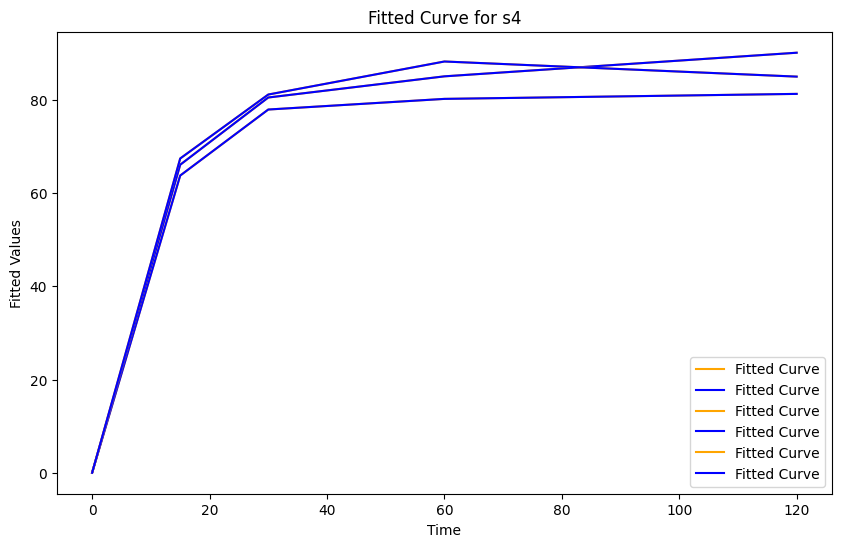

In [7]:
plt.figure(figsize=(10, 6))
for i in [1, 2, 3]:
    plt.plot(time, dataset['replicate_'+str(i)+'_fitted'], label='Fitted Curve', color='orange')
    plt.plot(time, dataset['replicate_'+str(i)], label='Fitted Curve', color='blue')
plt.xlabel('Time')
plt.ylabel('Fitted Values')
plt.title('Fitted Curve for s4')
plt.legend()
plt.show()

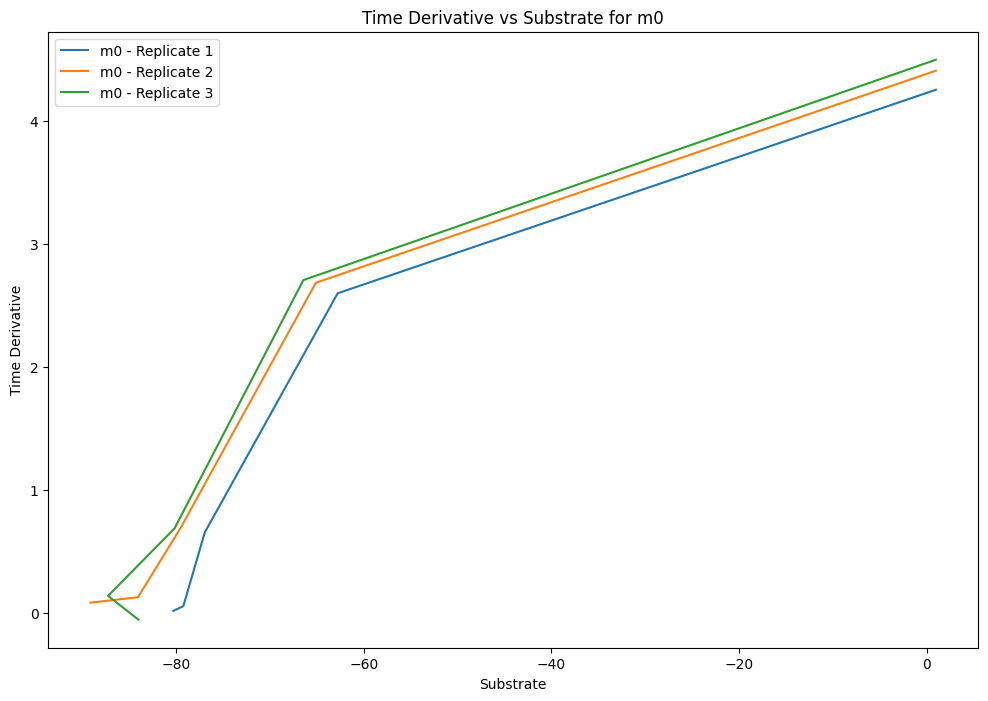

In [8]:
for key, dataset in data_dict.items():
    plt.figure(figsize=(12, 8))
    
    for derivative_col in [col for col in dataset.columns if col.startswith('derivative_')]:
        replicate_num = derivative_col.split('_')[1]
        substrate_col = f'substrate_{replicate_num}'
        
        plt.plot(dataset[substrate_col], dataset[derivative_col], label=f'{key} - Replicate {replicate_num}')
    
    plt.xlabel('Substrate')
    plt.ylabel('Time Derivative')
    plt.title(f'Time Derivative vs Substrate for {key}')
    plt.legend()
    plt.show()

In [9]:
trajectories = [data.iloc[i:i+56] for i in range(0, len(data), 56)]

In [10]:
for i in range(len(trajectories)):
    df = trajectories[i]
    trajectories[i]['K_M'] = ((df['k_cat'] + df['k_off'])/ (df['k_off'] * df['k_D']))
    trajectories[i]['mm'] = df['tK'] * df['P_u'] / (df['P_u'] + ((df['k_cat'] + df['k_off'])/ (df['k_off'] * df['k_D'])))
    print(trajectories[i])

KeyError: 'k_cat'

Scaling factor for trajectory 0: 3.576527688305813e-05


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


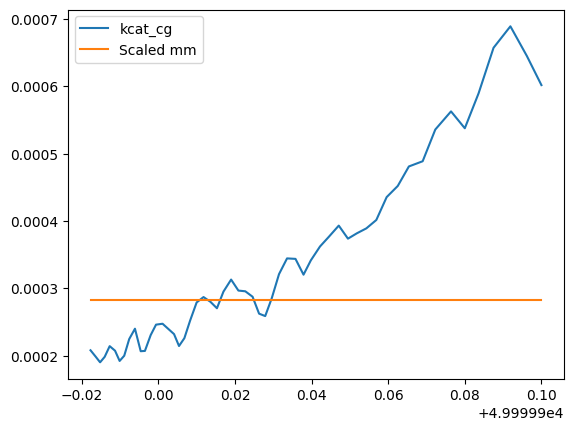

Scaling factor for trajectory 1: 7.118538483428583e-05


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


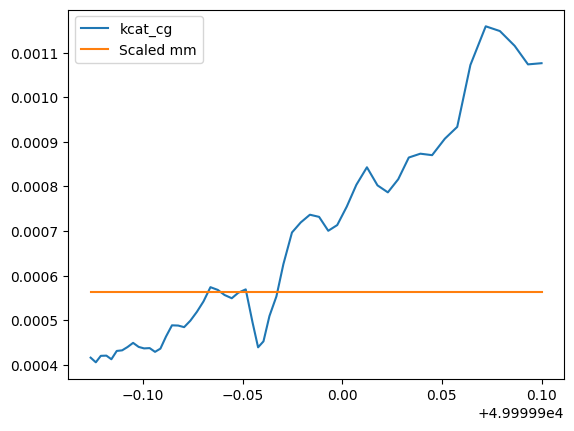

Scaling factor for trajectory 2: 9.953423731244564e-05


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


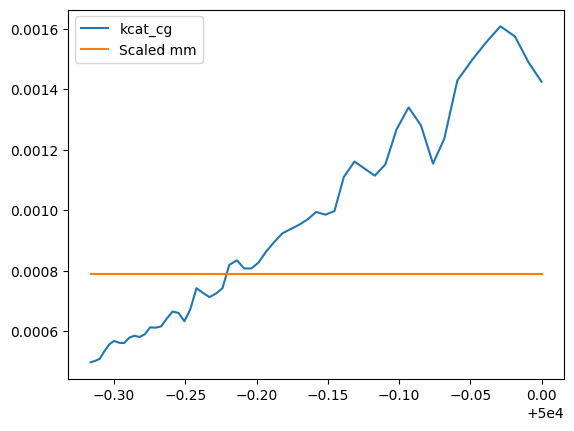

/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


Scaling factor for trajectory 3: 0.0001567732571140669


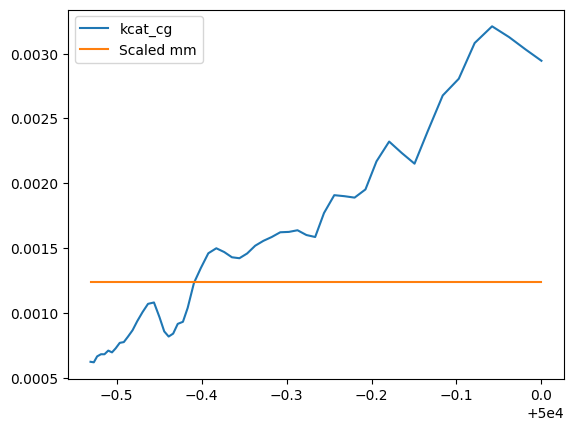

/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


Scaling factor for trajectory 4: 0.0001486564862000326


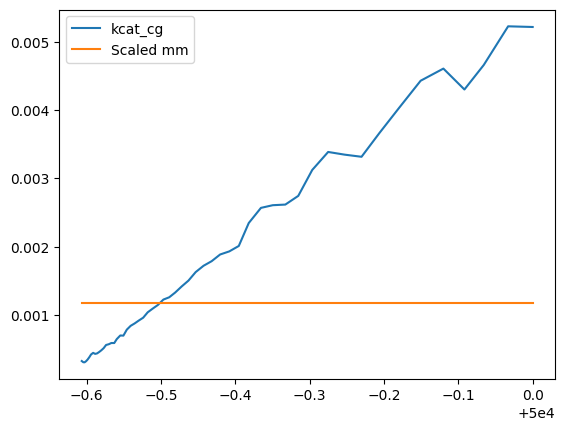

Scaling factor for trajectory 5: 8.952709489628507e-05


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


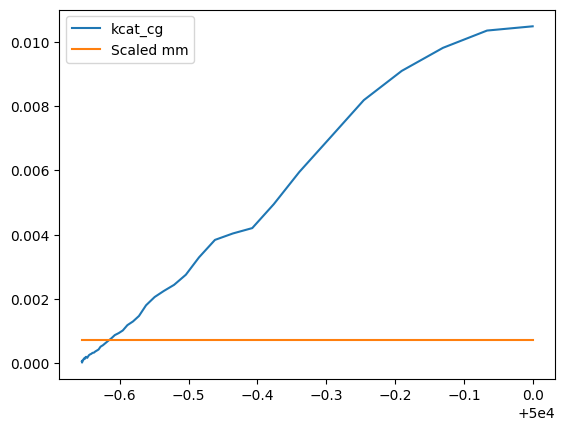

Scaling factor for trajectory 6: 4.059708517347429e-05


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


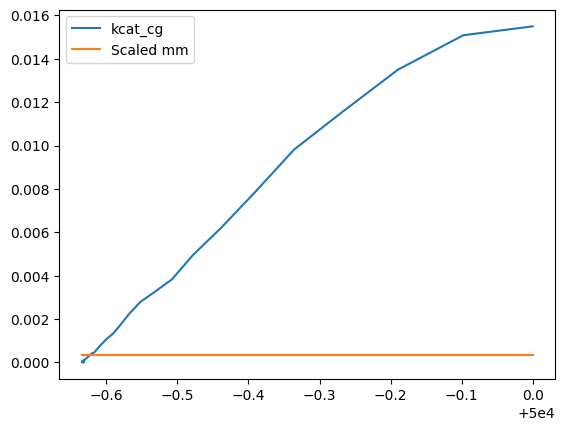

/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


Scaling factor for trajectory 7: 3.9518105806912904e-05


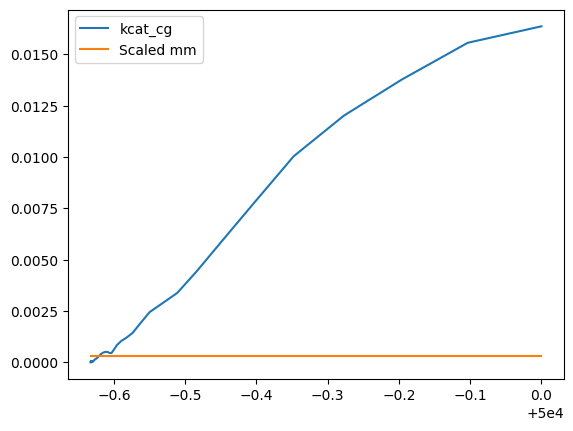

/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


Scaling factor for trajectory 8: 3.664692360146189e-05


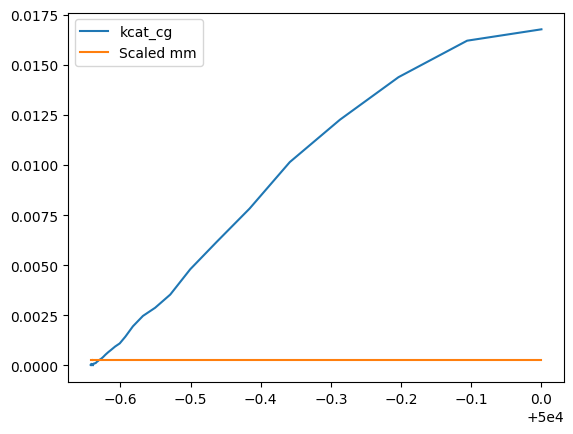

/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/4144733153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


Scaling factor for trajectory 9: 3.7062203095824614e-05


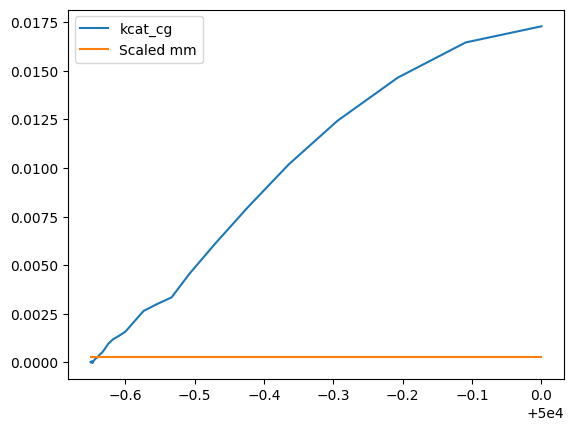

In [ ]:
for i, trajectory in enumerate(trajectories):
    # Smooth kcat_cg and calculate scaling factor
    trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']
    scaling_factor = (trajectory['kcat_cg_smoothed'][10:] / trajectory['mm'][10:]).mean()
    print(f"Scaling factor for trajectory {i}: {scaling_factor}")
    
    # Plot the scaled mm to match kcat_cg
    plt.plot(traj4abel='kcat_cg')
    plt.plot(trajectory['P_u'], trajectory['mm'] * scaling_factor, label='Scaled mm')
    plt.legend()
    plt.show()

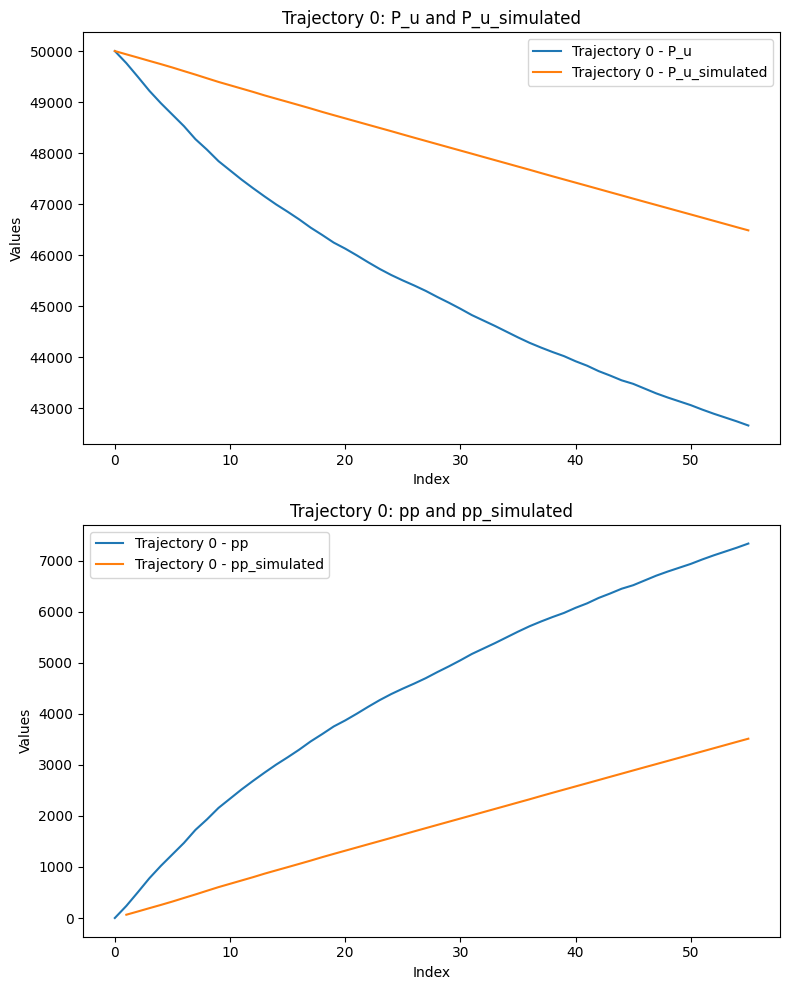

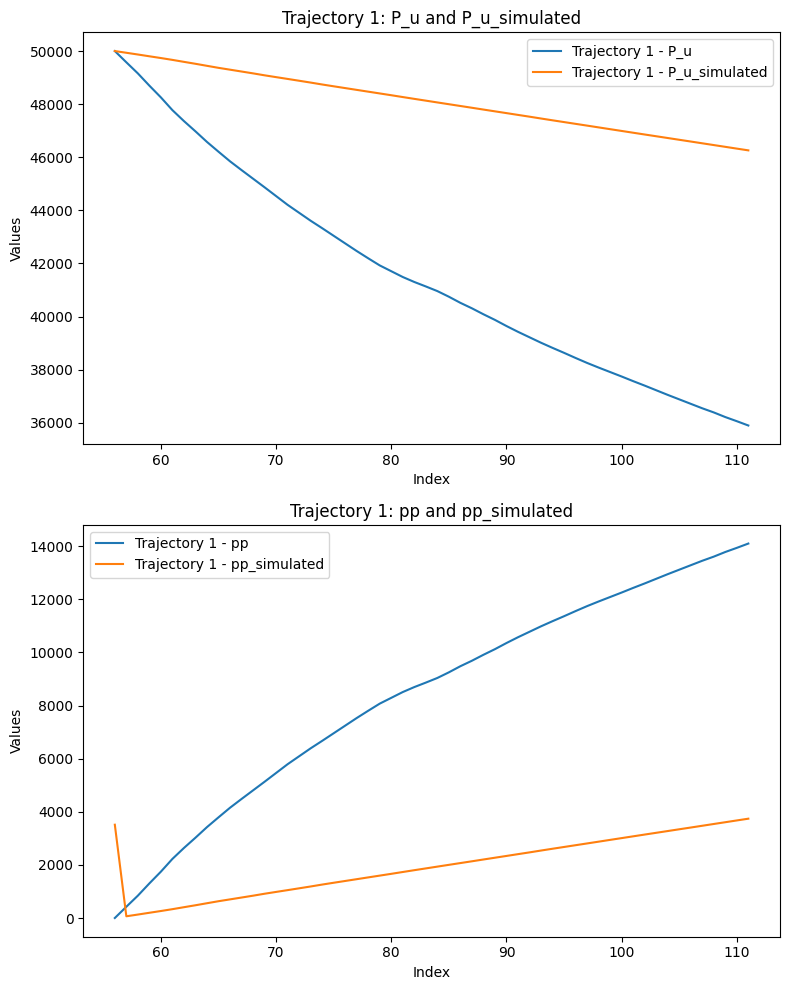

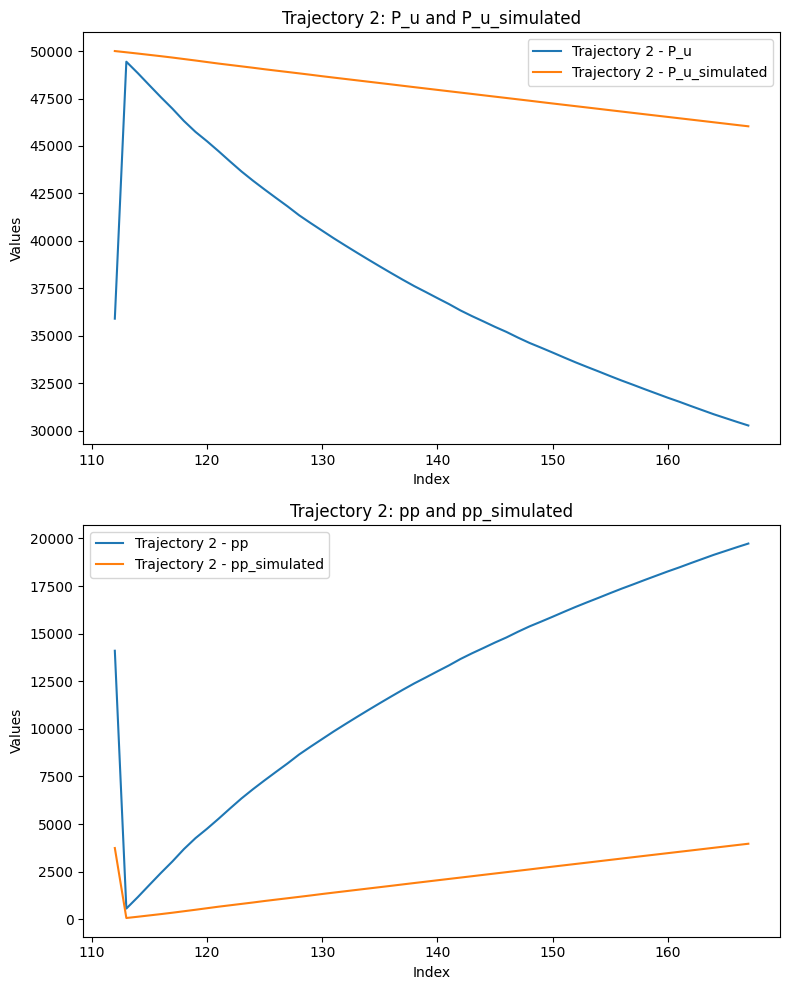

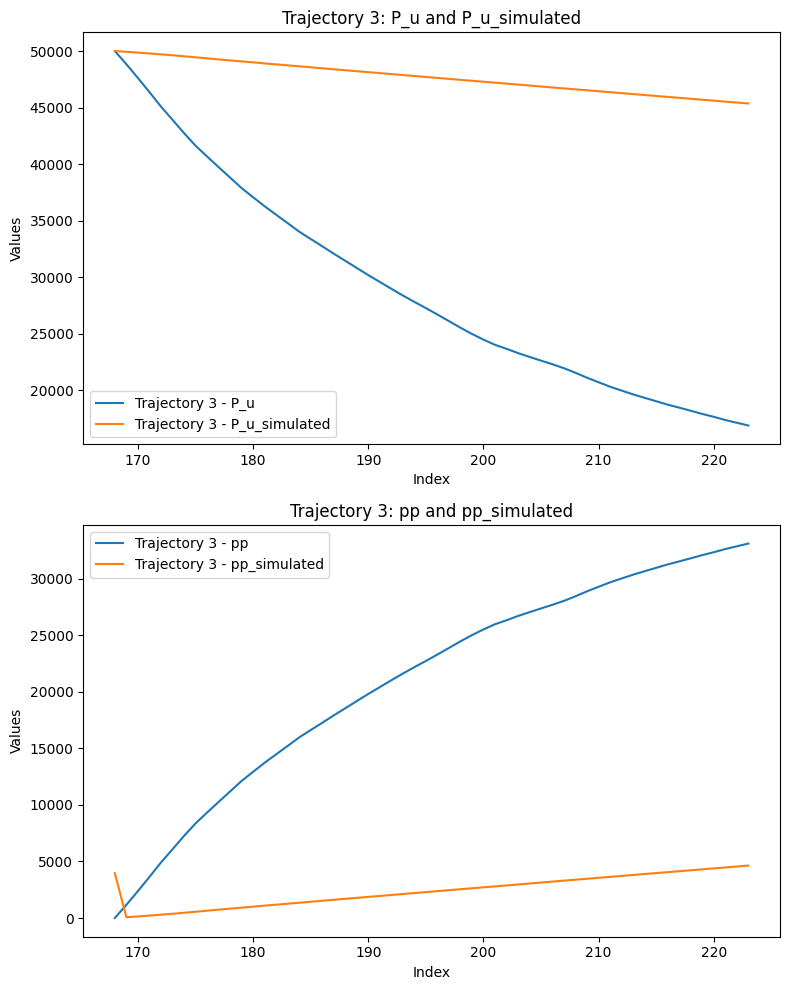

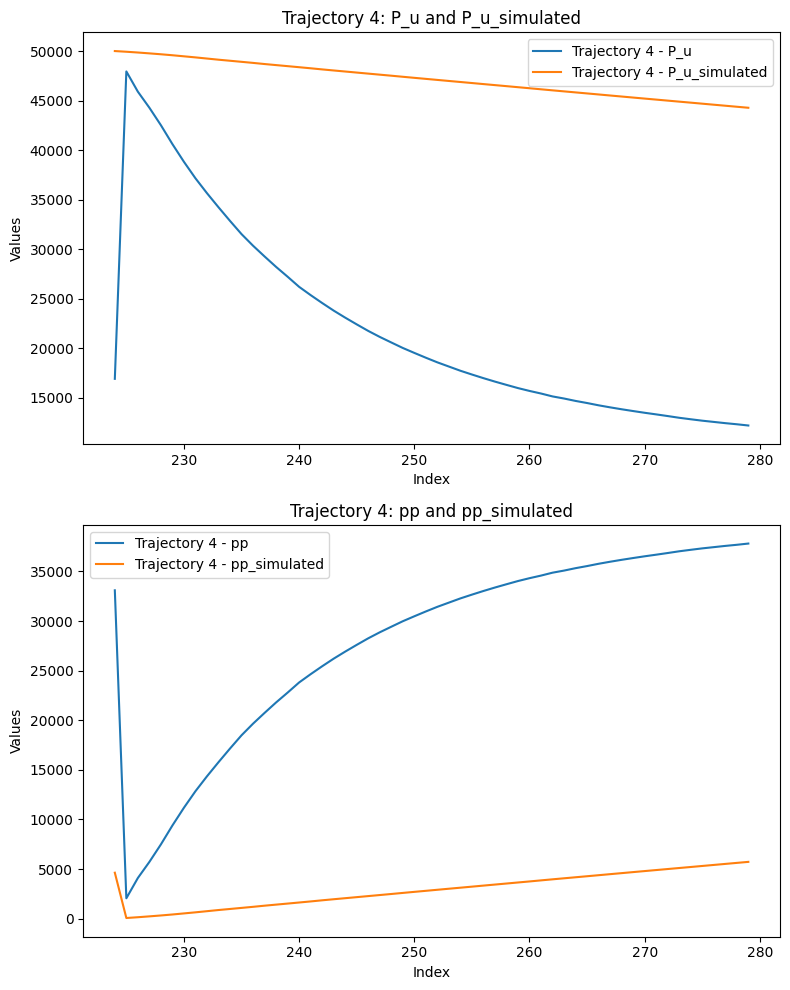

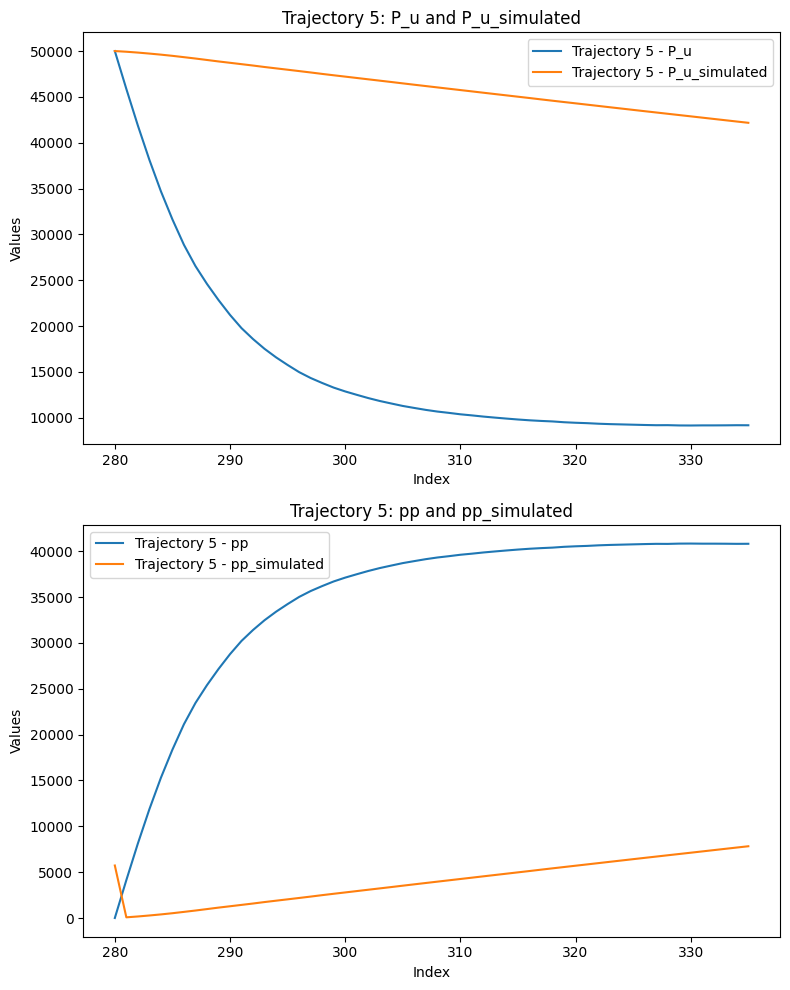

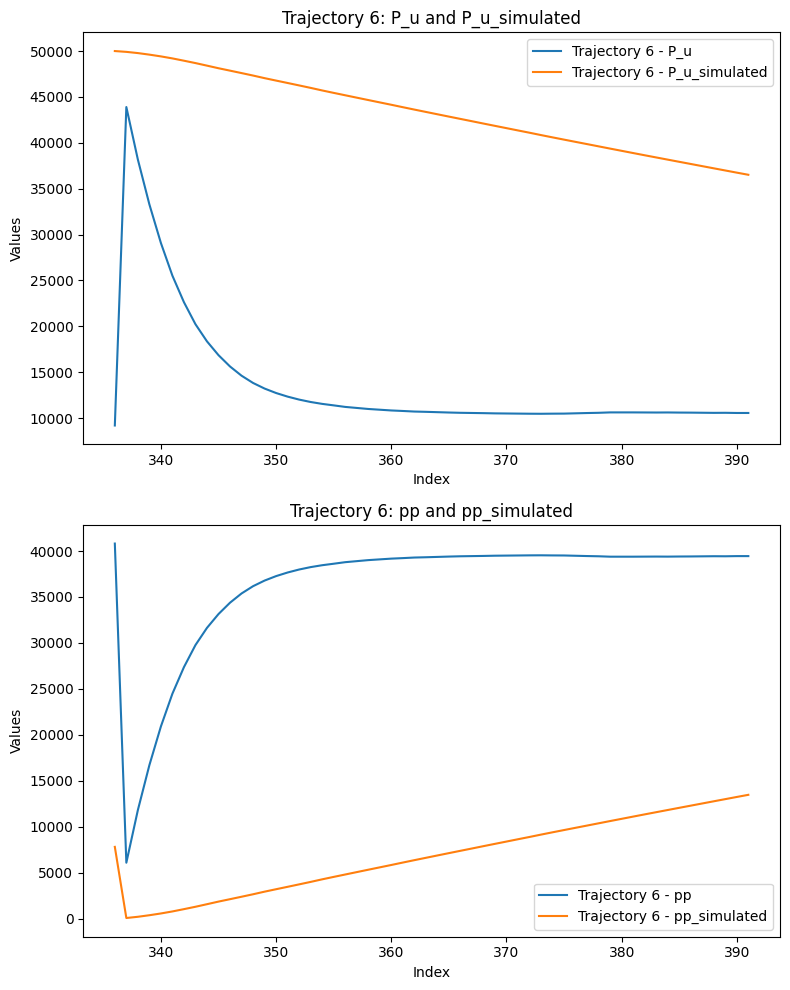

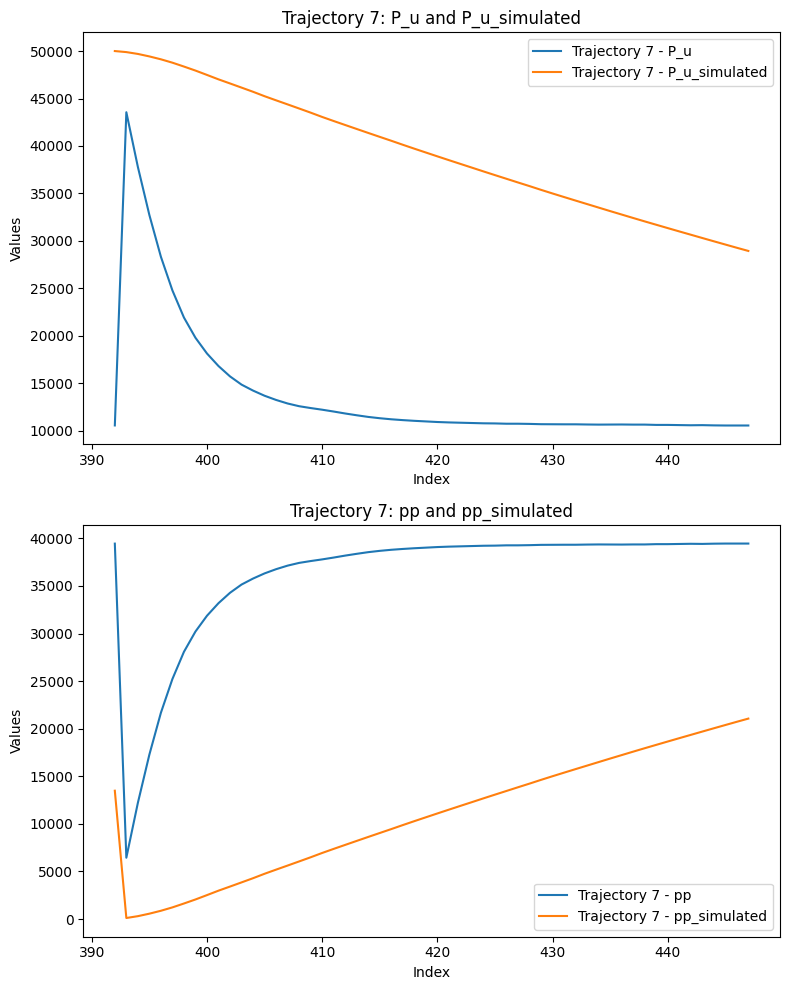

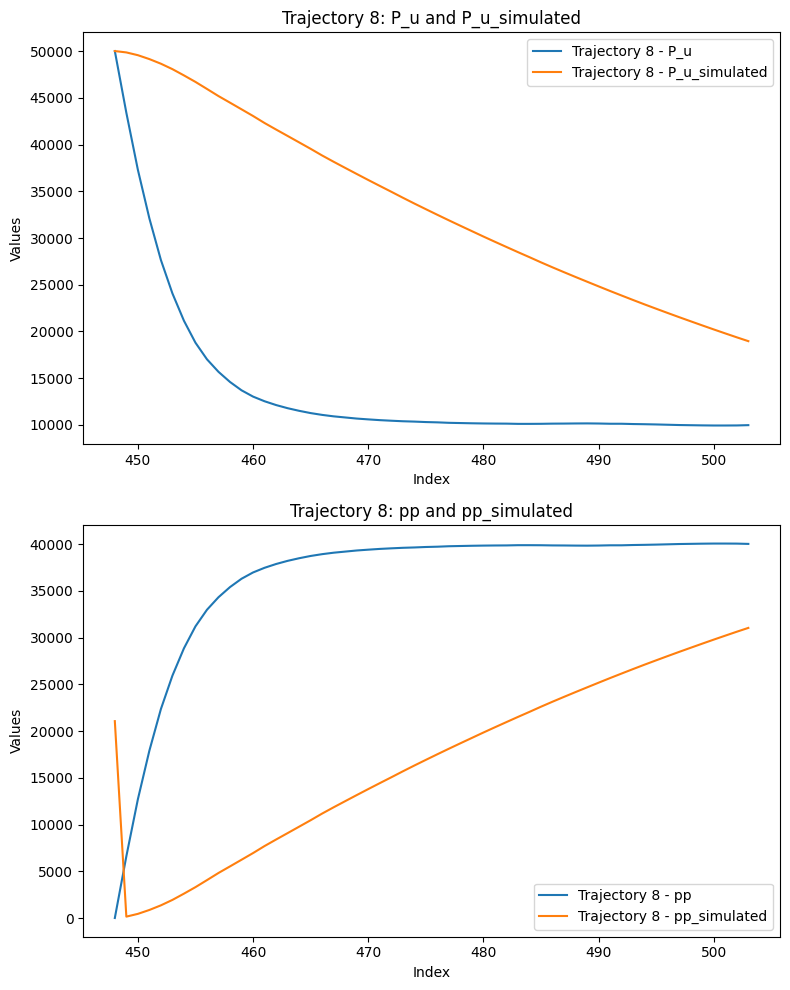

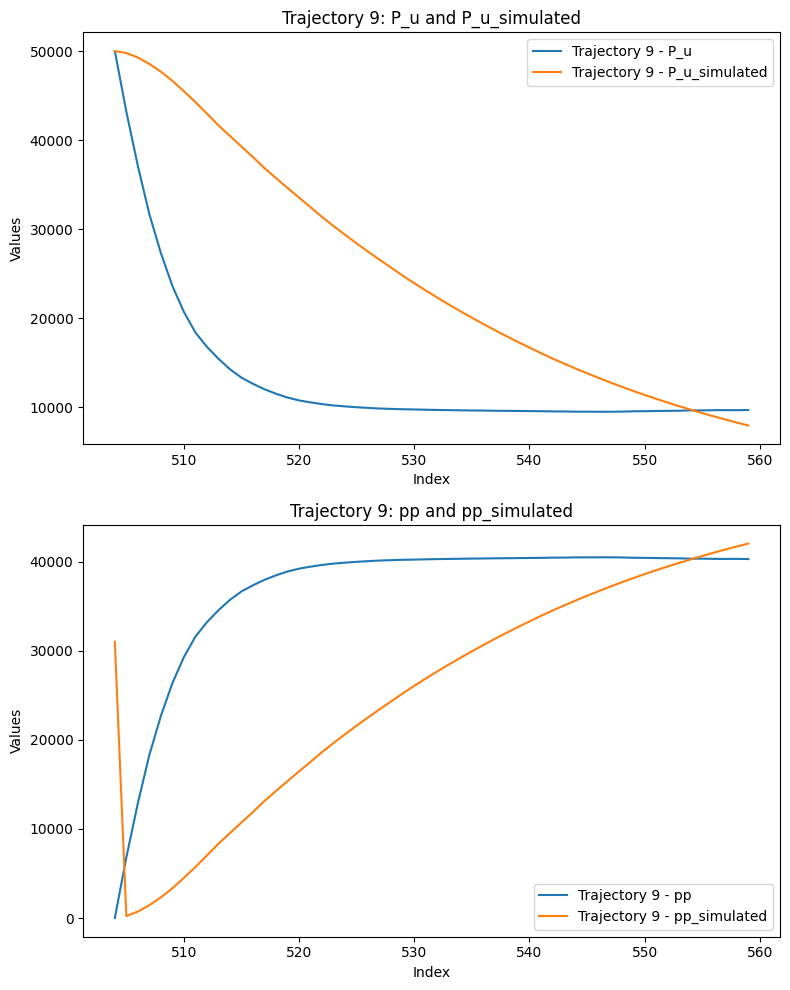

In [ ]:
for i, trajectory in enumerate(trajectories):
    fig, axs = plt.subplots(2, 1, figsize=(8, 10))

    # First subplot: P_u vs P_u_simulated
    axs[0].plot(50000-trajectory['P_p'] / SCALE_PRODUCT_C0, label=f'Trajectory {i} - P_u')
    axs[0].plot(trajectory['P_u_simulated'], label=f'Trajectory {i} - P_u_simulated')
    axs[0].set_xlabel('Index')
    axs[0].set_ylabel('Values')
    axs[0].set_title(f'Trajectory {i}: P_u and P_u_simulated')
    axs[0].legend()

    # Second subplot: pp vs pp_simulated
    axs[1].plot(trajectory['P_p'] / SCALE_PRODUCT_C0, label=f'Trajectory {i} - pp')
    axs[1].plot(trajectory['P_p_simulated'], label=f'Trajectory {i} - pp_simulated')
    axs[1].set_xlabel('Index')
    axs[1].set_ylabel('Values')
    axs[1].set_title(f'Trajectory {i}: pp and pp_simulated')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

Scaling factor for trajectory 0: 3.576527688305813e-05


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_83752/817116634.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']


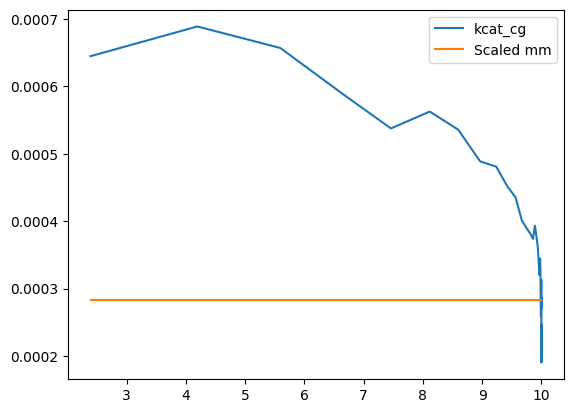

Scaling factor for trajectory 1: 7.118538483428583e-05


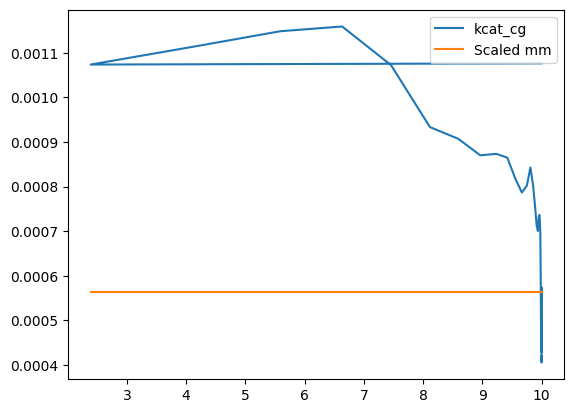

Scaling factor for trajectory 2: 9.953423731244564e-05


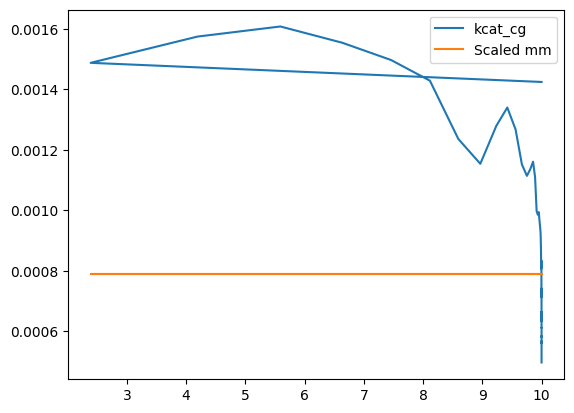

Scaling factor for trajectory 3: 0.0001567732571140669


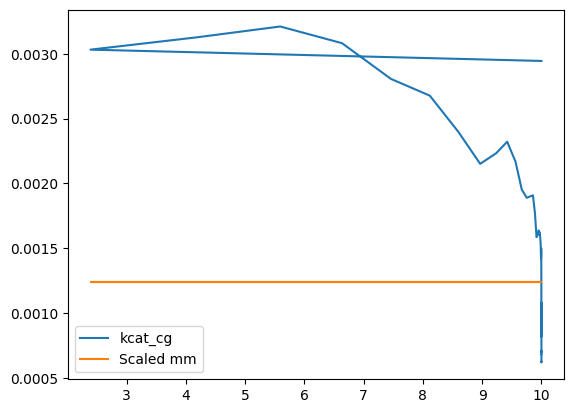

Scaling factor for trajectory 4: 0.0001486564862000326


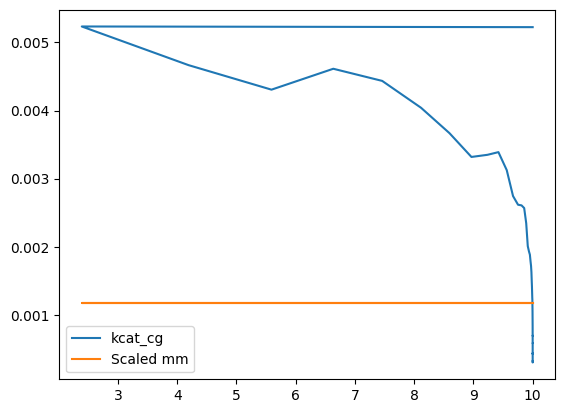

Scaling factor for trajectory 5: 8.952709489628507e-05


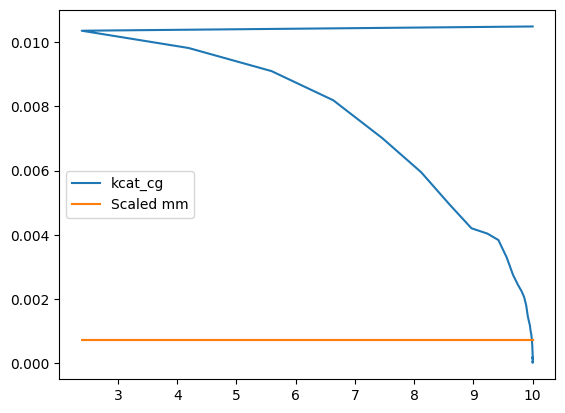

Scaling factor for trajectory 6: 4.059708517347429e-05


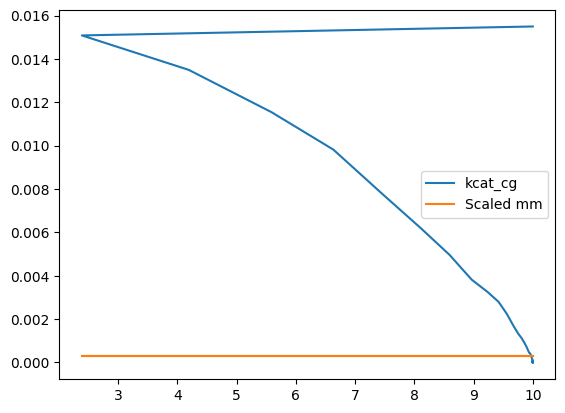

Scaling factor for trajectory 7: 3.9518105806912904e-05


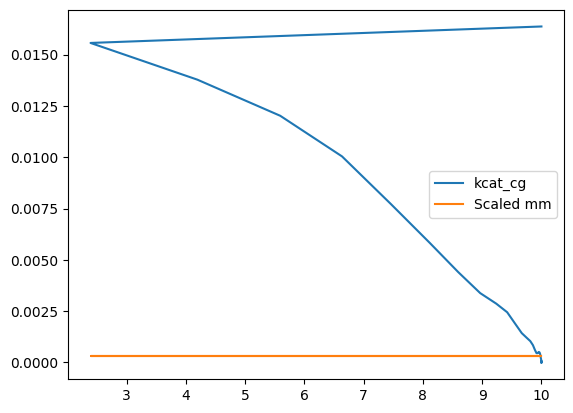

Scaling factor for trajectory 8: 3.664692360146189e-05


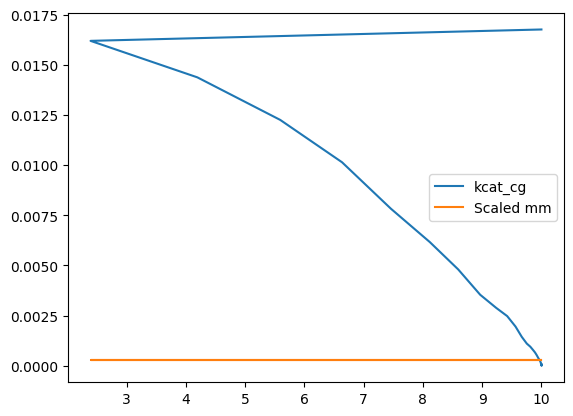

Scaling factor for trajectory 9: 3.7062203095824614e-05


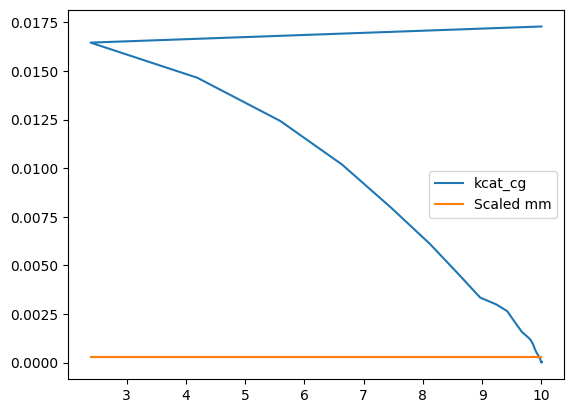

In [ ]:
for i, trajectory in enumerate(trajectories):
    # Smooth kcat_cg and calculate scaling factor
    trajectory['kcat_cg_smoothed'] = trajectory['kcat_cg']
    scaling_factor = (trajectory['kcat_cg_smoothed'][10:] / trajectory['mm'][10:]).mean()
    print(f"Scaling factor for trajectory {i}: {scaling_factor}")
    
    # Plot the scaled mm to match kcat_cg
    plt.plot(trajectory['mtx'], trajectory['kcat_cg_smoothed'], label='kcat_cg')
    plt.plot(trajectory['mtx'], trajectory['mm'] * scaling_factor, label='Scaled mm')
    plt.legend()
    plt.show()